# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1) We use general linear models/latent variable models/activation functions in analysis for non linear cases, especially when the outcome is not continuous. General linear models and activation functions allow us to transform the output so it fits the type of data we have, such as probabilities between 0 and 1. This makes them more flexible than standard linear regression, which can give unrealistic predictions that can be less than 0 or greater than 1.
2) Binary and categorical cross entropy are effective loss functions for fitting logistic regression models because they measure how far the predicted probabilities are from the true labels. They penalize wrong predictions, which helps the model learn better. Since logistic regression outputs probabilities, cross entropy is a good choice because it aligns well with maximizing likelihood.
3) This is true because although logistic regression uses a nonlinear activation function (sigmoid), the model is still linear in the parameters because it models a linear combination of the inputs before applying the transformation.
4) This is false. Logistic regression is typically used for classification since it outputs probabilities and we can control the outputs by creating restrictions at assign class labels.
5) No it does not because in logistic regression, coefficients represent the change in the log-odds, not the predicted probability directly. So a 1-unit increase in a feature changes the actual log-odds of the outcome. Not the probability. 
6) This is false because logistic regression is actually linear in the features, so it cannot capture complex relationships unless we create new interactions or transformations in the model. 
7) This is false because logistic regression is actually better for classification problems and linear regression is better for predicting continuous values. It is important to identify that each model is suited for different types of problems, so one is not always necessarily better than the other. 

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv', sep=';')

cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]
df = df[cols].copy()

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
df.dropna(inplace=True)
print('\nTarget distribution:')
print(df['Target'].value_counts())

# Binary target: 1 = Dropout, 0 = Graduate or Enrolled
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

features = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)'
]
X = df[features]
y = df['dropout']


Shape: (4424, 6)

Missing values:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [14]:
#Q2.2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print('Logistic Regression Coefficients:')
print(coef_df.to_string(index=False))
print('\nPositive coef → higher dropout probability')
print('Negative coef → lower dropout probability')

Logistic Regression Coefficients:
                            Feature  Coefficient
                  Age at enrollment     0.432540
                             Debtor     0.168602
                 Scholarship holder    -0.406173
            Tuition fees up to date    -0.797470
Curricular units 1st sem (approved)    -1.326350

Positive coef → higher dropout probability
Negative coef → lower dropout probability


Age at enrollment and Debtor seems to predict a higher dropout probability while Scholarship holder, tuition fees up to date and curricular units 1st sem (approved) seems to predict a lower dropout probability. Yes, being up to date on tuition seems to reduce dropout risk. 

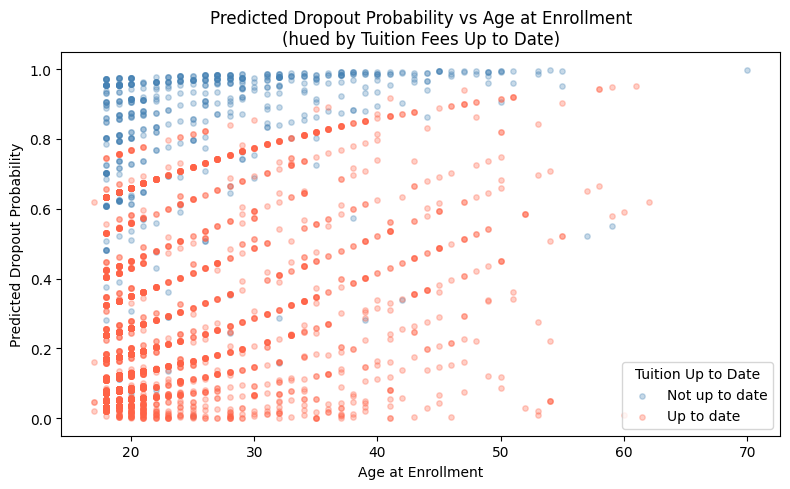

Avg dropout prob (up to date):     0.248
Avg dropout prob (not up to date): 0.865
Average reduction:                 0.617

Gap by age group:
Tuition fees up to date       gap
age_bin                          
(17, 22]                 0.616022
(22, 27]                 0.557538
(27, 32]                 0.523522
(32, 37]                 0.515457
(37, 42]                 0.469501
(42, 47]                 0.518286
(47, 52]                 0.406438
(52, 57]                 0.505465


In [15]:
#Q2.3
df['dropout_prob'] = log_reg.predict_proba(X_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Not up to date', 1: 'Up to date'}
for val in [0, 1]:
    subset = df[df['Tuition fees up to date'] == val]
    ax.scatter(subset['Age at enrollment'], subset['dropout_prob'],
               alpha=0.3, s=15, color=colors[val], label=labels[val])

ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Predicted Dropout Probability')
ax.set_title('Predicted Dropout Probability vs Age at Enrollment\n(hued by Tuition Fees Up to Date)')
ax.legend(title='Tuition Up to Date')
plt.tight_layout()
plt.show()

# Average effect of being up to date on tuition
avg_uptodate = df[df['Tuition fees up to date'] == 1]['dropout_prob'].mean()
avg_not = df[df['Tuition fees up to date'] == 0]['dropout_prob'].mean()
print(f'Avg dropout prob (up to date):     {avg_uptodate:.3f}')
print(f'Avg dropout prob (not up to date): {avg_not:.3f}')
print(f'Average reduction:                 {avg_not - avg_uptodate:.3f}')

# Gap by age group
df['age_bin'] = pd.cut(df['Age at enrollment'], bins=range(17, 60, 5))
gap = df.groupby(['age_bin', 'Tuition fees up to date'])['dropout_prob'].mean().unstack()
gap['gap'] = gap[0] - gap[1]
print('\nGap by age group:')
print(gap[['gap']].dropna())

Being up to date on tuition reduces dropout probability the most for younger students (ages 17-22), where the gap is 0. Being up to date on tuition reduces dropout probability the most for younger students (ages 17-22), where the gap is 0.616. The gap generally decreases as age increases, though it remains large across all age groups. On average, being up to date on tuition reduces the predicted probability of dropout by 0.617.

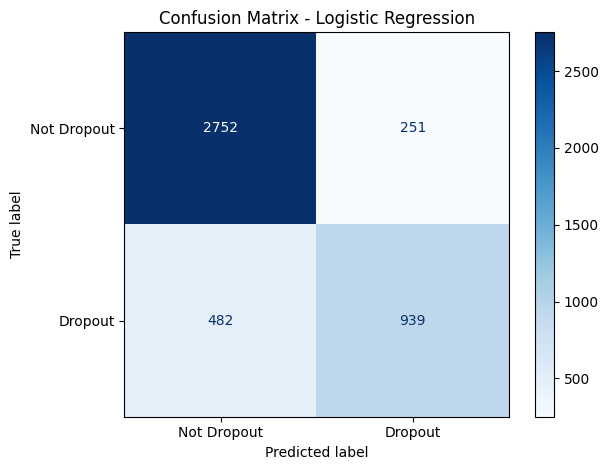

Accuracy: 0.8343


In [16]:
#Q2.4
y_pred = log_reg.predict(X_scaled)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Dropout', 'Dropout'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

print(f'Accuracy: {accuracy_score(y, y_pred):.4f}')

The accuracy is 0.8343. 

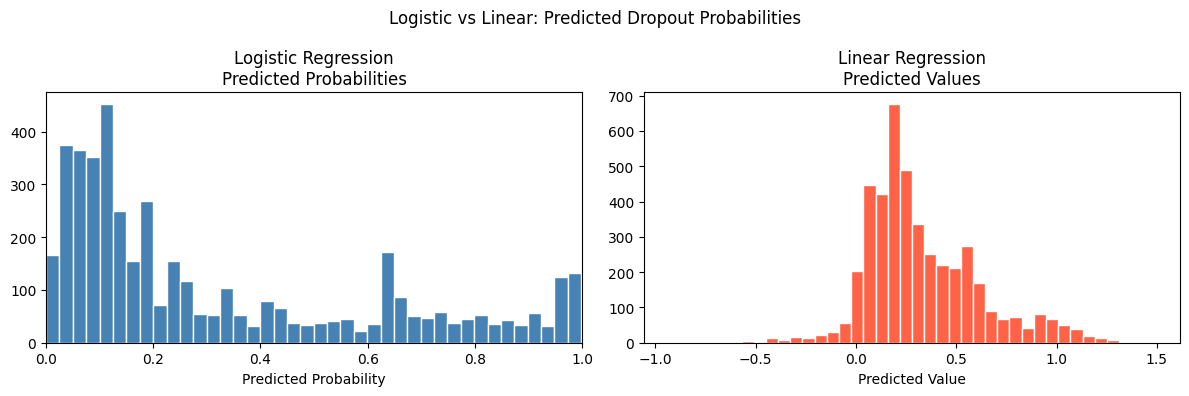

Linear range: -0.934 to 1.494
Linear can predict outside [0,1]; logistic is bounded to valid probabilities.


In [17]:
#Q2.5
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)
df['dropout_prob_linear'] = lin_reg.predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['dropout_prob'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression\nPredicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_xlim(0, 1)

axes[1].hist(df['dropout_prob_linear'], bins=40, color='tomato', edgecolor='white')
axes[1].set_title('Linear Regression\nPredicted Values')
axes[1].set_xlabel('Predicted Value')

plt.suptitle('Logistic vs Linear: Predicted Dropout Probabilities')
plt.tight_layout()
plt.show()

print('Linear range:', round(df['dropout_prob_linear'].min(), 3), 'to', round(df['dropout_prob_linear'].max(), 3))
print('Linear can predict outside [0,1]; logistic is bounded to valid probabilities.')

Q2.6

Students most at risk of dropping out are those with outstanding debt, tuition not up to date, no scholarship, older age at enrollment, and fewer first-semester courses passed. Some interventions that would help at risk students stay enrolled could be having emergency financial aid or flexible payment plans for students behind on tuition, or providing dedicated advising for older/non-traditional students who may be balancing work and family alongside school. 

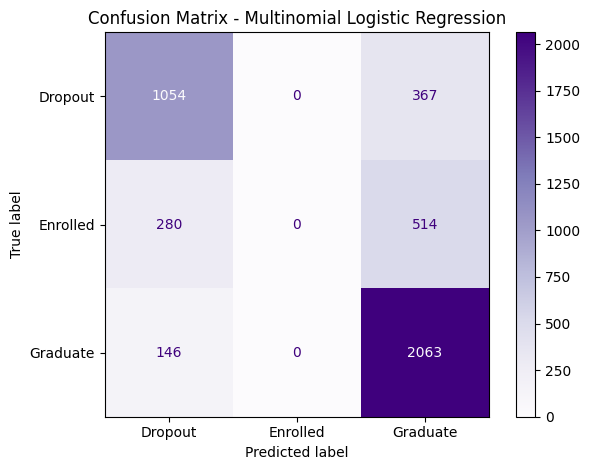

Accuracy: 0.7046

Sample predicted probabilities (first 5 rows):
    Dropout  Enrolled  Graduate
0  0.679467  0.210916  0.109617
1  0.705039  0.145407  0.149553
2  0.953949  0.040610  0.005441
3  0.117596  0.176845  0.705560
4  0.183821  0.212512  0.603667

Classes predicted by hard classification: {'Dropout', 'Graduate'}
predict_proba always outputs a column per class, so all 3 classes have predicted probabilities.


In [18]:
#Q2.7
features_multi = [
    'Debtor',
    'Tuition fees up to date',
    'Curricular units 1st sem (approved)'
]

X_multi = df[features_multi]
y_multi = df['Target'] 

X_multi_scaled = scaler.fit_transform(X_multi)

multi_log = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
multi_log.fit(X_multi_scaled, y_multi)

y_multi_pred = multi_log.predict(X_multi_scaled)

cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=multi_log.classes_)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=multi_log.classes_)
disp_multi.plot(cmap='Purples')
plt.title('Confusion Matrix - Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

print(f'Accuracy: {accuracy_score(y_multi, y_multi_pred):.4f}')

proba_multi = multi_log.predict_proba(X_multi_scaled)
proba_df = pd.DataFrame(proba_multi, columns=multi_log.classes_)
print('\nSample predicted probabilities (first 5 rows):')
print(proba_df.head())

print('\nClasses predicted by hard classification:', set(y_multi_pred))
print('predict_proba always outputs a column per class, so all 3 classes have predicted probabilities.')

No, the hard classification only predicts Dropout and Graduate. Enrolled never gets predicted, so the model can't really tell enrolled students apart from the other two classes with just these features. The predicted probabilities do cover all three classes though since predict_proba gives a column for each one with non-zero values. So the probabilities know all three classes exist but when it comes to actually picking a class, Enrolled is never the highest probability for any student.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [19]:
#Q3.1
import pandas as pd
df3 = pd.read_csv('cirrhosis.csv')

cols3 = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df3 = df3[cols3].copy()

print('Shape:', df3.shape)
print('\nMissing values:')
print(df3.isnull().sum())

df3.dropna(inplace=True)
print('\nShape after dropping NAs:', df3.shape)
print('\nStatus distribution:')
print(df3['Status'].value_counts())

# Binary target: 1 = Dead (D), 0 = Alive (C or CL)
df3['survived'] = (df3['Status'] != 'D').astype(int)
print('\nSurvived distribution (1=alive, 0=dead):')
print(df3['survived'].value_counts())

Shape: (418, 5)

Missing values:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Shape after dropping NAs: (312, 5)

Status distribution:
Status
C     168
D     125
CL     19
Name: count, dtype: int64

Survived distribution (1=alive, 0=dead):
survived
1    187
0    125
Name: count, dtype: int64


In [20]:
#Q3.2
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Encode categorical variables
df3['Drug_binary'] = (df3['Drug'] == 'D-penicillamine').astype(int)
df3['Edema_N'] = (df3['Edema'] == 'N').astype(int)
df3['Edema_S'] = (df3['Edema'] == 'S').astype(int)

features3 = ['Edema_N', 'Edema_S', 'Drug_binary', 'Bilirubin']
X3 = df3[features3]
y3 = df3['survived']

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

log3 = LogisticRegression(max_iter=1000, random_state=42)
log3.fit(X3_scaled, y3)

coef3 = pd.DataFrame({
    'Feature': features3,
    'Coefficient': log3.coef_[0]
}).sort_values('Coefficient', ascending=False)

print('Logistic Regression Coefficients (predicting survival):')
print(coef3.to_string(index=False))
print('\nDoes drug improve survival? Drug coef:', round(coef3.loc[coef3.Feature == "Drug_binary", "Coefficient"].values[0], 3))
print('(Positive = drug associated with higher survival probability)')
print('\nBilirubin coef:', round(coef3.loc[coef3.Feature == "Bilirubin", "Coefficient"].values[0], 3))
print('(Negative = higher bilirubin associated with lower survival)')
print('\nEdema Y (reference) vs N vs S: higher edema severity → lower survival')

Logistic Regression Coefficients (predicting survival):
    Feature  Coefficient
    Edema_N     0.875514
    Edema_S     0.521549
Drug_binary    -0.119267
  Bilirubin    -1.466402

Does drug improve survival? Drug coef: -0.119
(Positive = drug associated with higher survival probability)

Bilirubin coef: -1.466
(Negative = higher bilirubin associated with lower survival)

Edema Y (reference) vs N vs S: higher edema severity → lower survival


Based on the coefficients, the drug (D-penicillamine) actually has a slightly negative coefficient (-0.119), meaning it does not improve survival probability. Higher bilirubin predicts a lower survival rate since its coefficient is -1.466, so patients with more bilirubin in their blood are less likely to survive. For edema, having no edema (Edema_N) has the highest coefficient at 0.876, and edema resolvable with diuretics (Edema_S) is at 0.521, both compared to the reference category of edema despite diuretics. So basically the worse the edema, the lower the survival rate.

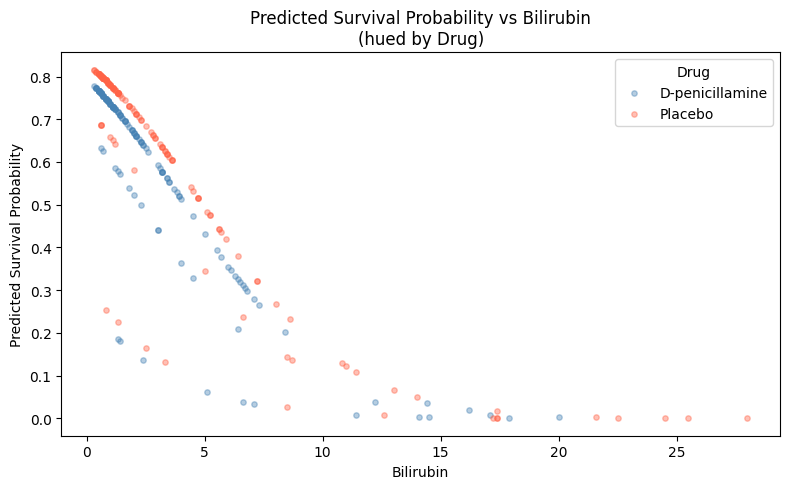

Drug benefit (D-pen minus Placebo) by Bilirubin level:
Drug                gap
bilirubin_bin          
(0, 1]        -0.028645
(1, 3]        -0.059901
(3, 6]        -0.052751
(6, 10]        0.021477
(10, 30]      -0.020620

Avg survival prob (drug):    0.589
Avg survival prob (placebo): 0.610
Average increase from drug:  -0.021


In [21]:
#Q3.3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

df3['survival_prob'] = log3.predict_proba(X3_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
colors3 = {'D-penicillamine': 'steelblue', 'Placebo': 'tomato'}
for drug in ['D-penicillamine', 'Placebo']:
    subset = df3[df3['Drug'] == drug]
    ax.scatter(subset['Bilirubin'], subset['survival_prob'],
               alpha=0.4, s=15, color=colors3[drug], label=drug)

ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival Probability vs Bilirubin\n(hued by Drug)')
ax.legend(title='Drug')
plt.tight_layout()
plt.show()

df3['bilirubin_bin'] = pd.cut(df3['Bilirubin'], bins=[0, 1, 3, 6, 10, 30])
gap3 = df3.groupby(['bilirubin_bin', 'Drug'])['survival_prob'].mean().unstack()
gap3['gap'] = gap3['D-penicillamine'] - gap3['Placebo']
print('Drug benefit (D-pen minus Placebo) by Bilirubin level:')
print(gap3[['gap']].dropna())

# Average increase in survival probability from drug
avg_drug = df3[df3['Drug'] == 'D-penicillamine']['survival_prob'].mean()
avg_placebo = df3[df3['Drug'] == 'Placebo']['survival_prob'].mean()
print(f'\nAvg survival prob (drug):    {avg_drug:.3f}')
print(f'Avg survival prob (placebo): {avg_placebo:.3f}')
print(f'Average increase from drug:  {avg_drug - avg_placebo:.3f}')

The drug only seems to slightly increase survival probability for patients with bilirubin levels between 6 and 10, where the gap is 0.021. For all other bilirubin ranges the drug actually performs slightly worse than placebo. On average, patients who take the drug have a lower survival probability than those on placebo by about 0.021, so the drug does not really increase survival probability overall.

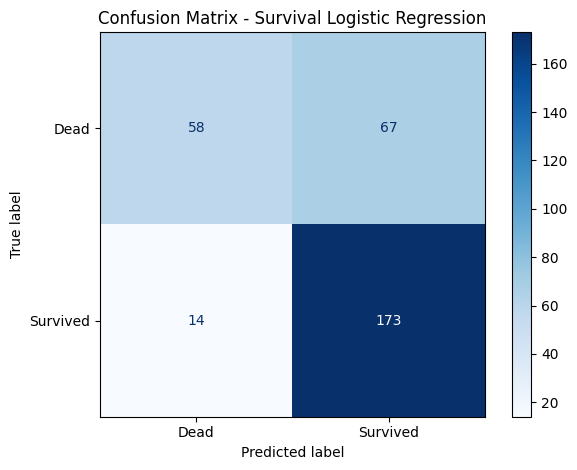

Accuracy: 0.7404


In [22]:
#Q3.4

y3_pred = log3.predict(X3_scaled)

cm3 = confusion_matrix(y3, y3_pred)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['Dead', 'Survived'])
disp3.plot(cmap='Blues')
plt.title('Confusion Matrix - Survival Logistic Regression')
plt.tight_layout()
plt.show()

print(f'Accuracy: {accuracy_score(y3, y3_pred):.4f}')

The accuracy is 0.7404. 

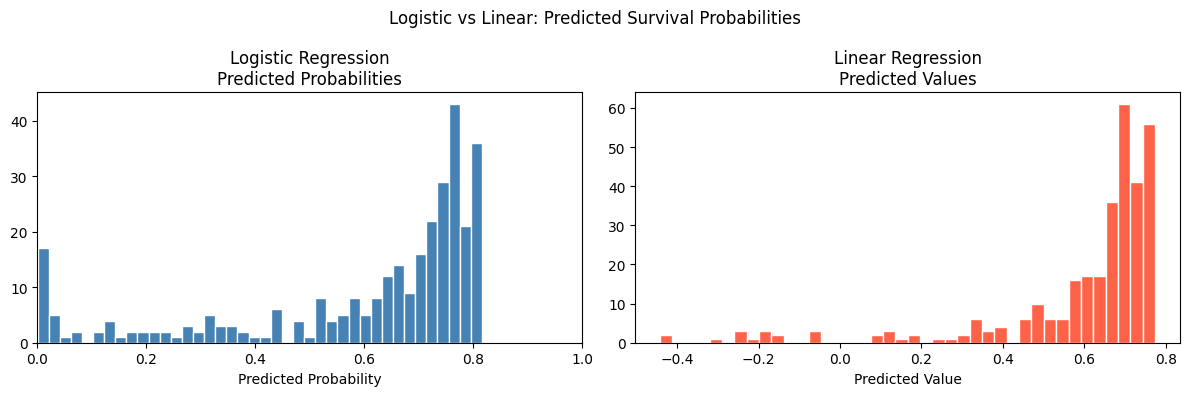

Linear range: -0.442 to 0.774
Linear can predict outside [0,1]; logistic is bounded to valid probabilities.


In [23]:
#Q3.5

lin3 = LinearRegression()
lin3.fit(X3_scaled, y3)
df3['survival_prob_linear'] = lin3.predict(X3_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df3['survival_prob'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression\nPredicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_xlim(0, 1)

axes[1].hist(df3['survival_prob_linear'], bins=40, color='tomato', edgecolor='white')
axes[1].set_title('Linear Regression\nPredicted Values')
axes[1].set_xlabel('Predicted Value')

plt.suptitle('Logistic vs Linear: Predicted Survival Probabilities')
plt.tight_layout()
plt.show()

print('Linear range:', round(df3['survival_prob_linear'].min(), 3), 'to', round(df3['survival_prob_linear'].max(), 3))
print('Linear can predict outside [0,1]; logistic is bounded to valid probabilities.')

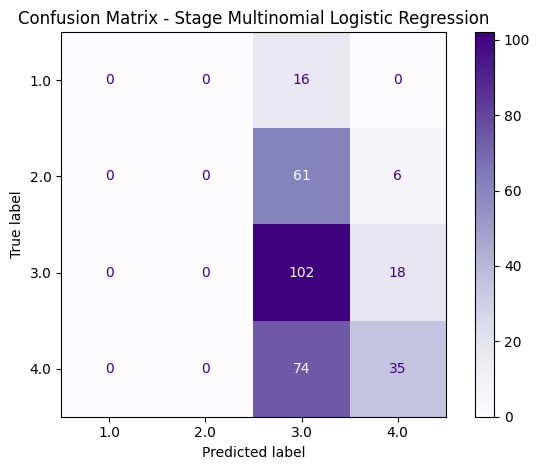

Accuracy: 0.4391

Sample predicted probabilities (first 5 rows):
        1.0       2.0       3.0       4.0
0  0.000130  0.025638  0.128264  0.845967
1  0.073092  0.252766  0.398411  0.275730
2  0.004111  0.173240  0.401823  0.420825
3  0.003625  0.167973  0.400929  0.427474
4  0.037600  0.224642  0.417494  0.320264

Classes predicted (hard): {'4.0', '3.0'}
All classes in data: {'4.0', '1.0', '2.0', '3.0'}

Hard classification may miss rare classes; predict_proba always outputs all classes.


In [24]:
#Q3.6

features3_multi = ['Edema_N', 'Edema_S', 'Bilirubin']
X3_multi = df3[features3_multi]
y3_multi = df3['Stage'].astype(str) 

X3_multi_scaled = scaler3.fit_transform(X3_multi)

multi3 = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
multi3.fit(X3_multi_scaled, y3_multi)

y3_multi_pred = multi3.predict(X3_multi_scaled)

cm3_multi = confusion_matrix(y3_multi, y3_multi_pred, labels=multi3.classes_)
disp3_multi = ConfusionMatrixDisplay(confusion_matrix=cm3_multi, display_labels=multi3.classes_)
disp3_multi.plot(cmap='Purples')
plt.title('Confusion Matrix - Stage Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

print(f'Accuracy: {accuracy_score(y3_multi, y3_multi_pred):.4f}')

proba3_multi = multi3.predict_proba(X3_multi_scaled)
proba3_df = pd.DataFrame(proba3_multi, columns=multi3.classes_)
print('\nSample predicted probabilities (first 5 rows):')
print(proba3_df.head())

print('\nClasses predicted (hard):', set(y3_multi_pred))
print('All classes in data:', set(y3_multi))
print('\nHard classification may miss rare classes; predict_proba always outputs all classes.')

No, the hard classification only predicts stages 3.0 and 4.0, missing stages 1.0 and 2.0 entirely. So the model can't really differentiate early stage patients from later ones using just edema and bilirubin. The predicted probabilities do cover all four stages though since predict_proba outputs a column for each class with non-zero values for every row. So the probabilities recognize all stages exist but when it comes to actually picking one, stages 1 and 2 never end up being the highest probability for any patient.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

Q4.1: 
For the linear model, the derivative with respect to the k-th feature is just b_k. So a 1 unit increase in x_k changes the prediction by exactly b_k, regardless of the current value of x.

Q4.2:
The derivative is maximized when p_hat = 0.5, where p_hat(1-p_hat) =0.25. Thus, the maximum effect of x_k on the prediction is approximately b_k *0.25, so the coefficient itself times 4 is roughly a good estimate of the maximum change in predicted probability.

Q4.3: 
A 1 unit increase in x_k increases the log odds ratio by b_k, regardless of the current value of x. This is constant like the linear model, but it operates on the log odds scale rather than the probability scale directly.